<a href="https://colab.research.google.com/github/SiminAlibani/EEG-signal-processing/blob/master/RawSpike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install nptdms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 7.8 MB/s eta 0:00:00


In [3]:
from nptdms import TdmsFile


In [4]:
tdms = TdmsFile.read("/content/channelik4_1.tdms")



[nptdms.reader WARNING] Last segment of file has less data than expected, will attempt to read to the end of the file
[nptdms.tdms_segment WARNING] Data size 8387339 is not a multiple of the chunk size 16000. Will attempt to read last chunk


In [5]:
print(tdms)
print(tdms.groups)

<bound method TdmsFile.groups of <nptdms.tdms.TdmsFile object at 0x78a0e8738aa0>>


In [6]:
for g in tdms.groups():
    print(g.name)

channelik4


In [7]:
for g in tdms.groups():
    print("Group:", g.name)

    for ch in g.channels():
        print(ch.name)

Group: channelik4
Spike_IT


In [8]:
for g in tdms.groups():
    for ch in g.channels():
        print(ch.name, len(ch))

Spike_IT 2096834


In [9]:
for g in tdms.groups():
    for ch in g.channels():
        print(ch.properties)

OrderedDict({'description': '', 'unit_string': '', 'Physical Channel': 4, 'Gain': 10000, 'LCF': 300, 'HCF': 9000, 'Spiky': False})


In [10]:
channel = tdms.groups()[0].channels()[0]

print(channel.data_type)

<class 'nptdms.types.SingleFloat'>


In [11]:
import numpy as np

data = channel[:]

print(data.dtype)

float32


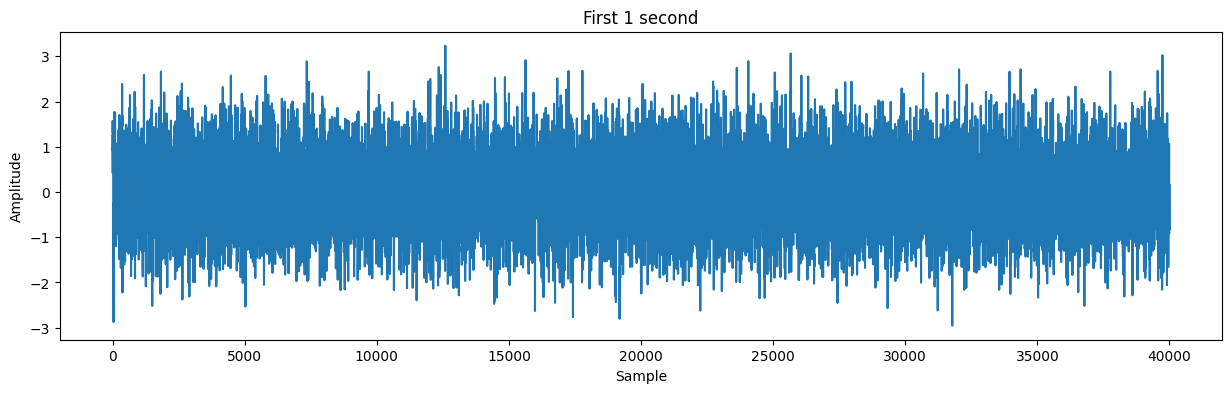

In [12]:
import matplotlib.pyplot as plt

channel = tdms.groups()[0].channels()[0]
data = channel[:]

fs = 40000

plt.figure(figsize=(15,4))
plt.plot(data[:fs])
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 1 second")
plt.show()

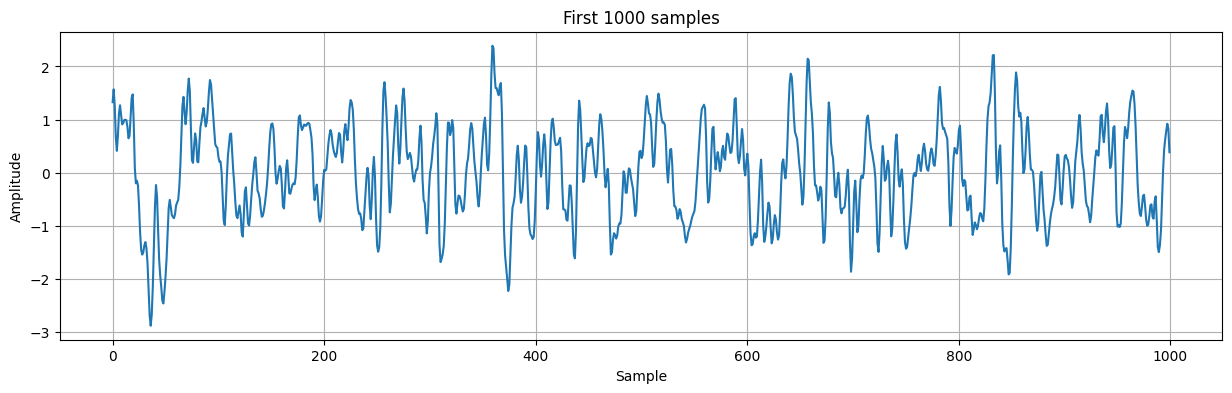

In [13]:
plt.figure(figsize=(15,4))
plt.plot(data[:1000])
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 1000 samples")
plt.grid(True)
plt.show()

In [14]:
import numpy as np

print("Shape:", data.shape)
print("Mean :", np.mean(data))
print("Median:", np.median(data))
print("Std :", np.std(data))
print("Min :", np.min(data))
print("Max :", np.max(data))
print("dtype:", data.dtype)

Shape: (2096834,)
Mean : 0.020719433
Median: 0.017041232
Std : 0.83682305
Min : -4.3798265
Max : 4.495417
dtype: float32


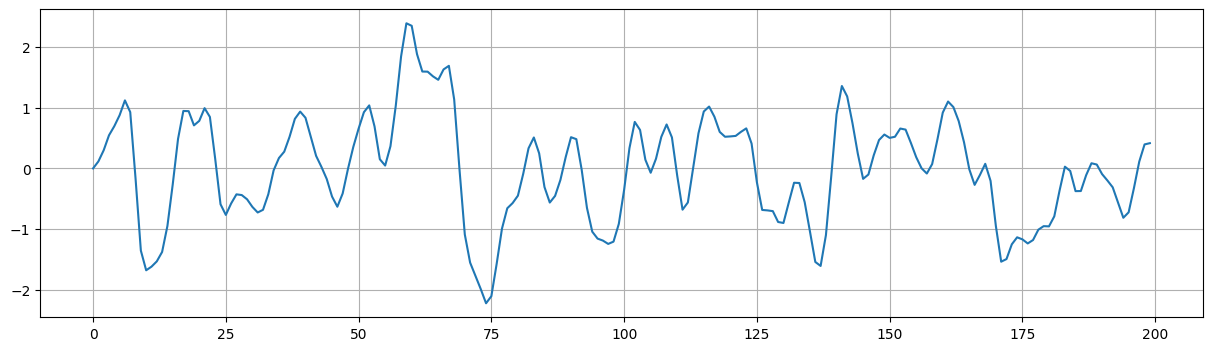

In [15]:
plt.figure(figsize=(15,4))
plt.plot(data[300:500])
plt.grid(True)
plt.show()